## **2. Data Understanding**  
**Pemahaman data** merupakan tahap awal dalam proses *Knowledge Discovery in Databases (KDD)* atau *Data Mining*. Langkah ini bertujuan untuk mengeksplorasi, menyelidiki, dan menganalisis dataset agar dapat memahami struktur, isi, serta karakteristik data sebelum melakukan analisis lebih lanjut.  

Pemahaman data yang baik sangat penting karena berpengaruh terhadap keberhasilan seluruh proses *data mining*, termasuk tahap *data preparation*, *modeling*, dan *evaluation*.  

---
### **Tujuan Pemahaman Data**  
1. **Memahami Konteks Data** – Mengenali sumber data, makna setiap variabel, serta hubungan antarvariabel dalam dataset.  
2. **Mengidentifikasi Permasalahan dalam Data** – Menemukan *missing values*, *outliers*, *noise*, atau ketidakkonsistenan dalam data.  
3. **Menilai Kualitas Data** – Memastikan bahwa data memiliki tingkat akurasi, kelengkapan, dan relevansi yang cukup untuk dianalisis.  
4. **Menentukan Arah Analisis** – Berdasarkan pemahaman awal, dapat dirumuskan hipotesis serta teknik *data mining* yang sesuai.  

---
### **Tahapan dalam Memahami Data**  
Berikut adalah beberapa langkah dalam memahami data:



## **1. Pengumpulan Data**
Dataset **IRIS** adalah Dataset ini berisi informasi tentang tiga spesies bunga Iris (*Setosa, Versicolor, Virginica*), dengan empat fitur utama: panjang dan lebar sepal serta panjang dan lebar petal.

---
#### **Lokasi Data**
Data **IRIS** yang digunakan berada dalam cloud data platform **aiven** dan **Dbeaver** untuk kelola database :
- Data IRIS petal berada di database  **MySQL**.
- Data IRIS sepal berada di database  **PostgreSQL**.

---
#### **Metode Pengumpulan Data**
Langkah pengumpulan data dilakukan dengan Python menggunakan pustaka berikut:  

1. **pymysql** → Untuk menghubungkan dan mengambil data dari MySQL.  
2. **pandas** → Untuk membaca dan mengolah data setelah diambil dari database.  
3. **psycopg2-binary** → Untuk menghubungkan dan mengambil data dari PostgreSQL.  
4. **sqlalchemy** → Untuk membuat koneksi database yang lebih stabil dan kompatibel dengan `pandas.read_sql()`.  
5. **python-dotenv** → Untuk menyimpan kredensial database dalam file `.env` agar lebih aman dan tidak perlu hardcoding dalam kode Python.
---
#### **Cara Mengumpulkan Data**

##### **1. Menghubungkan ke MySQL dan PostgreSQL**
- Install library python yang diperlukan




In [1]:
!pip install pymysql
!pip install pandas
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.6 MB/s eta 0:00:00


- buat file env untuk koneksi database di aiven anda.


Sesuaikan seperti format dibawah ini:
```python
# Database MySQL
MYSQL_HOST=<HOSTNAME>
MYSQL_USER=<USERNAME>
MYSQL_PASSWORD=<PASSWORD>
MYSQL_PORT=<PORT>
MYSQL_DATABASE=<DATABASE_NAME>

# Database PostgreSQL
PG_HOST=<HOSTNAME>
PG_USER=<USERNAME>
PG_PASSWORD=<PASSWORD>
PG_PORT=<PORT>
PG_DATABASE=<DATABASE_NAME>
```

Upload env:

In [ ]:
from google.colab import files
uploaded = files.upload()

- koneksikan database di aiven

In [3]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

# Ambil variabel koneksi dari lingkungan
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

PG_HOST = os.getenv("PG_HOST")
PG_PORT = os.getenv("PG_PORT")
PG_USER = os.getenv("PG_USER")
PG_PASSWORD = os.getenv("PG_PASSWORD")
PG_DATABASE = os.getenv("PG_DATABASE")

# Gunakan SQLAlchemy untuk koneksi ke MySQL
mysql_engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")

# Gunakan SQLAlchemy untuk koneksi ke PostgreSQL
pg_engine = create_engine(f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}")


##### **2. Mengambil dan menampilkan data**

In [4]:
try:
    # Query MySQL
    mysql_query = "SELECT * FROM petal_data;"
    df_mysql = pd.read_sql(mysql_query, mysql_engine)

    # Query PostgreSQL
    pg_query = "SELECT * FROM sepal_data;"
    df_postgres = pd.read_sql(pg_query, pg_engine)

    # Print hasil query
    print("Data dari MySQL:")
    print(df_mysql.head())

    print("\nData dari PostgreSQL:")
    print(df_postgres.head())

    # Jika data berhasil diambil, hapus file .env
    if os.path.exists(".env"):
        os.remove(".env")

except Exception as e:
    print(f"Gagal mengambil data: {e}")

Data dari MySQL:
   id        Class  petal length  petal width
0   1  Iris-setosa          86.4         70.0
1   2  Iris-setosa           1.4          0.2
2   3  Iris-setosa           1.3          0.2
3   4  Iris-setosa           1.5          0.2
4   5  Iris-setosa           1.4          0.2

Data dari PostgreSQL:
   id        Class  sepal length  sepal width
0   2  Iris-setosa           4.9          3.0
1   3  Iris-setosa           4.7          3.2
2   4  Iris-setosa           4.6          3.1
3   5  Iris-setosa           5.0          3.6
4   6  Iris-setosa           5.4          3.9



##### **6. Menggabungkan Data dari Kedua Database**



In [22]:
# Menggabungkan data dari MySQL (df_mysql) dan PostgreSQL (df_postgres) berdasarkan kolom 'id'
df_combined = pd.merge(
    df_mysql,  # Data dari MySQL yang berisi informasi petal
    df_postgres.drop(columns=['Class']),  # Menghapus kolom 'Class' dari df_postgres sebelum penggabungan
    on="id",  # Menggabungkan berdasarkan kolom 'id' yang harus ada di kedua dataframe
    how="inner"  # Menggunakan inner join, hanya menyertakan data dengan 'id' yang ada di kedua tabel
)

# Menampilkan hasil penggabungan
print("\nData gabungan:")
print(df_combined)



Data gabungan:
      id           Class  petal length  petal width  sepal length  sepal width
0      1     Iris-setosa          86.4         70.0          20.1         30.5
1      2     Iris-setosa           1.4          0.2           4.9          3.0
2      3     Iris-setosa           1.3          0.2           4.7          3.2
3      4     Iris-setosa           1.5          0.2           4.6          3.1
4      5     Iris-setosa           1.4          0.2           5.0          3.6
..   ...             ...           ...          ...           ...          ...
145  146  Iris-virginica           5.2          2.3           6.7          3.0
146  147  Iris-virginica           5.0          1.9           6.3          2.5
147  148  Iris-virginica           5.2          2.0           6.5          3.0
148  149  Iris-virginica           5.4          2.3           6.2          3.4
149  150  Iris-virginica           5.1          1.8           5.9          3.0

[150 rows x 6 columns]


### 2. **Profiling data**

Profiling data adalah langkah penting dalam memahami karakteristik dataset sebelum melakukan analisis lebih lanjut.

---
#### **Ringkasan variabel dalam dataset**

- Menampilkan Informasi Dataset

In [6]:
# Menampilkan informasi struktur DataFrame setelah penggabungan
print(df_combined.info())  # Menampilkan jumlah baris, kolom, tipe data, dan jumlah nilai non-null di setiap kolom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            150 non-null    int64  
 1   Class         150 non-null    object 
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   sepal length  150 non-null    float64
 5   sepal width   150 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


- **Total data:** 150 baris, 6 kolom  
- **Kolom & tipe data:**  
  - `id` → **int64** (bilangan bulat)  
  - `Class` → **object** (kategori)  
  - `petal length`, `petal width`, `sepal length`, `sepal width` → **float64** (angka desimal)  
- **Tidak ada nilai kosong** (**150 non-null** untuk semua kolom)  
---

- Menampilkan Ringkasan Statistik untuk Variabel Numerik

In [7]:
# Menampilkan statistik deskriptif untuk semua kolom numerik, kecuali 'id'
print(df_combined.drop(columns=['id']).describe())



       petal length  petal width  sepal length  sepal width
count    150.000000    150.00000    150.000000   150.000000
mean       4.325333      1.66400      5.943333     3.234000
std        6.970563      5.66807      1.426895     2.282464
min        1.000000      0.10000      4.300000     2.000000
25%        1.600000      0.30000      5.100000     2.800000
50%        4.400000      1.30000      5.800000     3.000000
75%        5.100000      1.80000      6.400000     3.300000
max       86.400000     70.00000     20.100000    30.500000


**Penjelasan Statistik Deskriptif:**  
- **Total data:** 150 sampel  
- **Nilai rata-rata (mean)**:  
  - petal length: **4.33**, petal width: **1.66**  
  - sepal length: **5.94**, sepal width: **3.23**  
- **Standar deviasi (std)** → Menunjukkan sebaran data  
  - petal width & sepal width memiliki nilai **std tinggi**, menunjukkan variasi besar  
- **Nilai minimum (min) & maksimum (max)**  
  - petal length mencapai **86.4**, sepal length **20.1**, sepal width **30.5**
- **Kuartil (25%, 50%, 75%)**  
  - 50% (median) menunjukkan distribusi tengah dari dataset

---
- Menampilkan Statistik untuk Variabel Kategorikal

In [8]:
# Menampilkan jumlah sampel untuk setiap kategori di kolom 'Class'
print(df_combined['Class'].value_counts())



Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


 **Penjelasan Distribusi Kelas:**  
- Dataset memiliki **3 kelas** (spesies bunga Iris):  
  - **Iris-setosa** → **50 sampel**  
  - **Iris-versicolor** → **50 sampel**  
  - **Iris-virginica** → **50 sampel**  
- **Distribusi kelas seimbang** (**masing-masing 50 sampel**)  
---

### 3. **Korelasi dan asosiasi**
#### **Memahami hubungan antar variabel**

- Menghitung Korelasi Antar Variabel Numerik

In [9]:
# Menghitung korelasi antar fitur numerik dengan metode Pearson
# Kolom 'id' dan 'Class' dihapus karena 'id' bukan fitur numerik yang relevan
df_corr = df_combined.drop(columns=['id', 'Class']).corr()

# Menampilkan matriks korelasi
print(df_corr)


              petal length  petal width  sepal length  sepal width
petal length      1.000000     0.991532      0.916142     0.930563
petal width       0.991532     1.000000      0.871461     0.964198
sepal length      0.916142     0.871461      1.000000     0.789396
sepal width       0.930563     0.964198      0.789396     1.000000


 **Penjelasan Korelasi Antar Fitur:**  
- **Nilai korelasi berkisar antara -1 hingga 1:**  
  - **Mendekati 1** → Hubungan positif kuat (saling meningkat)  
  - **Mendekati -1** → Hubungan negatif kuat (satu naik, yang lain turun)  
  - **Mendekati 0** → Tidak ada hubungan  

**Analisis Korelasi:**  
**petal length & petal width** → **Korelasi sangat kuat (0.99)** → Jika panjang kelopak besar, lebarnya juga besar  
**sepal length & petal length** → **Korelasi tinggi (0.91)** → Panjang sepal cenderung meningkat seiring panjang petal  
**sepal width & petal width** → **Korelasi kuat (0.96)** → Lebar sepal berhubungan erat dengan lebar petal  

---

**Visualisasi**:

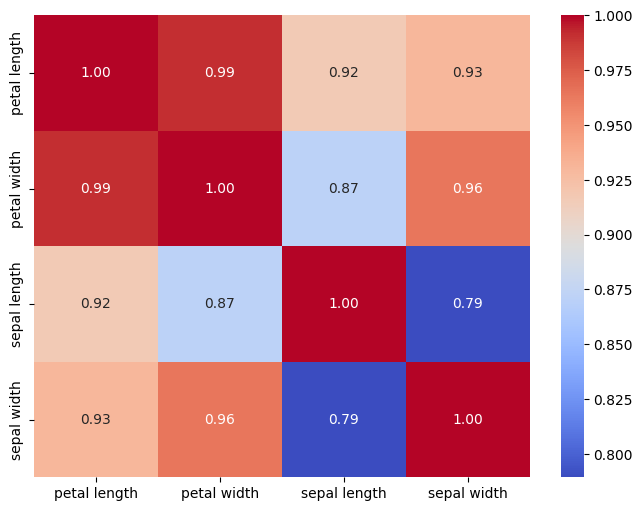

In [13]:
# Import library untuk visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat figure dengan ukuran 8x6
plt.figure(figsize=(8,6))

# Membuat heatmap untuk menampilkan korelasi antar fitur
# annot=True → Menampilkan nilai korelasi di dalam setiap sel
# cmap='coolwarm' → Menggunakan skema warna merah-biru untuk membedakan korelasi positif dan negatif
# fmt=".2f" → Menampilkan angka dengan dua desimal
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")

# Menampilkan heatmap
plt.show()


- Statistik Deskriptif Per Class

In [14]:
# Menghitung rata-rata setiap fitur numerik berdasarkan kelas ('Class')
# Kolom 'id' dihapus karena tidak relevan dalam perhitungan rata-rata
df_mean = df_combined.drop(columns=['id']).groupby('Class').mean()

# Menampilkan hasil rata-rata per kelas
print(df_mean)



                 petal length  petal width  sepal length  sepal width
Class                                                                
Iris-setosa             3.164        1.640         5.306        3.958
Iris-versicolor         4.260        1.326         5.936        2.770
Iris-virginica          5.552        2.026         6.588        2.974


**Rata-rata Fitur Berdasarkan Kelas (Spesies Bunga Iris):**  
- **Iris-setosa** → **Petal lebih pendek dan sepal lebih lebar** dibandingkan spesies lain.  
- **Iris-versicolor** → **Ukuran petal dan sepal berada di antara Setosa & Virginica**.  
- **Iris-virginica** → **Petal & sepal paling panjang dan lebar**, menunjukkan ukuran terbesar.  

**Visualisasi**:

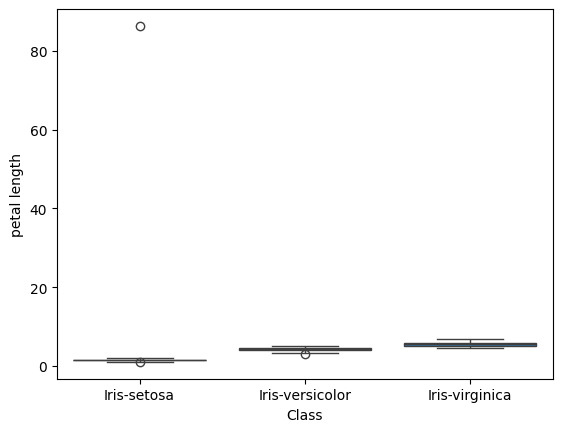

In [23]:
# Membuat boxplot untuk melihat distribusi 'petal length' berdasarkan kelas ('Class')
sns.boxplot(x="Class", y="petal length", data=df_combined)

# Menampilkan plot
plt.show()



### 4. **Eksplorasi Data**
Eksplorasi data bertujuan untuk memahami distribusi variabel, hubungan antar fitur, serta mendeteksi masalah seperti outliers atau missing values.

---
#### 1. Distribusi Data Numerik
Menggunakan Histogram untuk melihat sebaran nilai dari setiap fitur numerik.

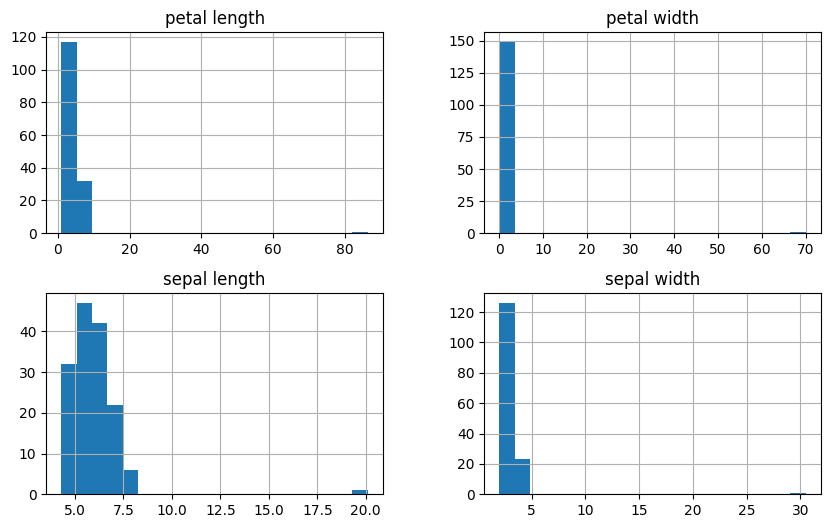

In [24]:
# Membuat histogram untuk semua kolom kecuali 'id'
# figsize=(10, 6) → Menentukan ukuran figure
# bins=20 → Membagi data ke dalam 20 interval
df_combined.loc[:, df_combined.columns != 'id'].hist(figsize=(10, 6), bins=20)

# Menampilkan histogram
plt.show()



Histogram ini menunjukkan adanya **nilai outlier yang signifikan** dalam dataset:  

- **Petal length** memiliki nilai yang mencapai **>80**, padahal seharusnya di bawah 7.  
- **Petal width** mencapai **>70**, yang tidak wajar dibandingkan dengan data normal.  
- **Sepal length** dan **sepal width** juga memiliki nilai ekstrem yang tidak biasa.  


#### 2. Distribusi Data tiap kategori
Menggunakan box plot untuk melihat tiap kategori.

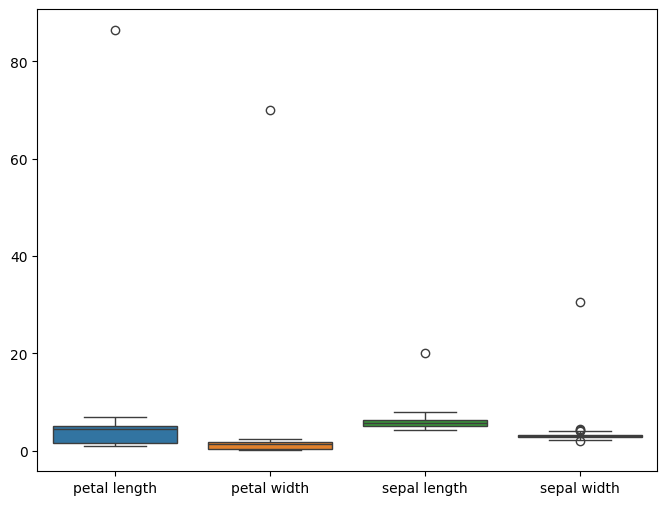

In [25]:
# Membuat figure dengan ukuran 8x6
plt.figure(figsize=(8,6))

# Membuat boxplot untuk melihat distribusi dan outlier pada semua fitur numerik
# Kolom 'id' dihapus karena tidak relevan dalam analisis
sns.boxplot(data=df_combined.loc[:, df_combined.columns != 'id'])

# Menampilkan plot
plt.show()



Boxplot ini menunjukkan adanya outlier ekstrem di dataset:

- Petal length memiliki nilai yang mencapai >80, yang jauh dari distribusi normal.
- Petal width, sepal length, dan sepal width juga memiliki outlier yang signifikan.

#### 3. Hubungan Antar Variabel
Scatter plot membantu melihat hubungan antara dua variabel numerik.

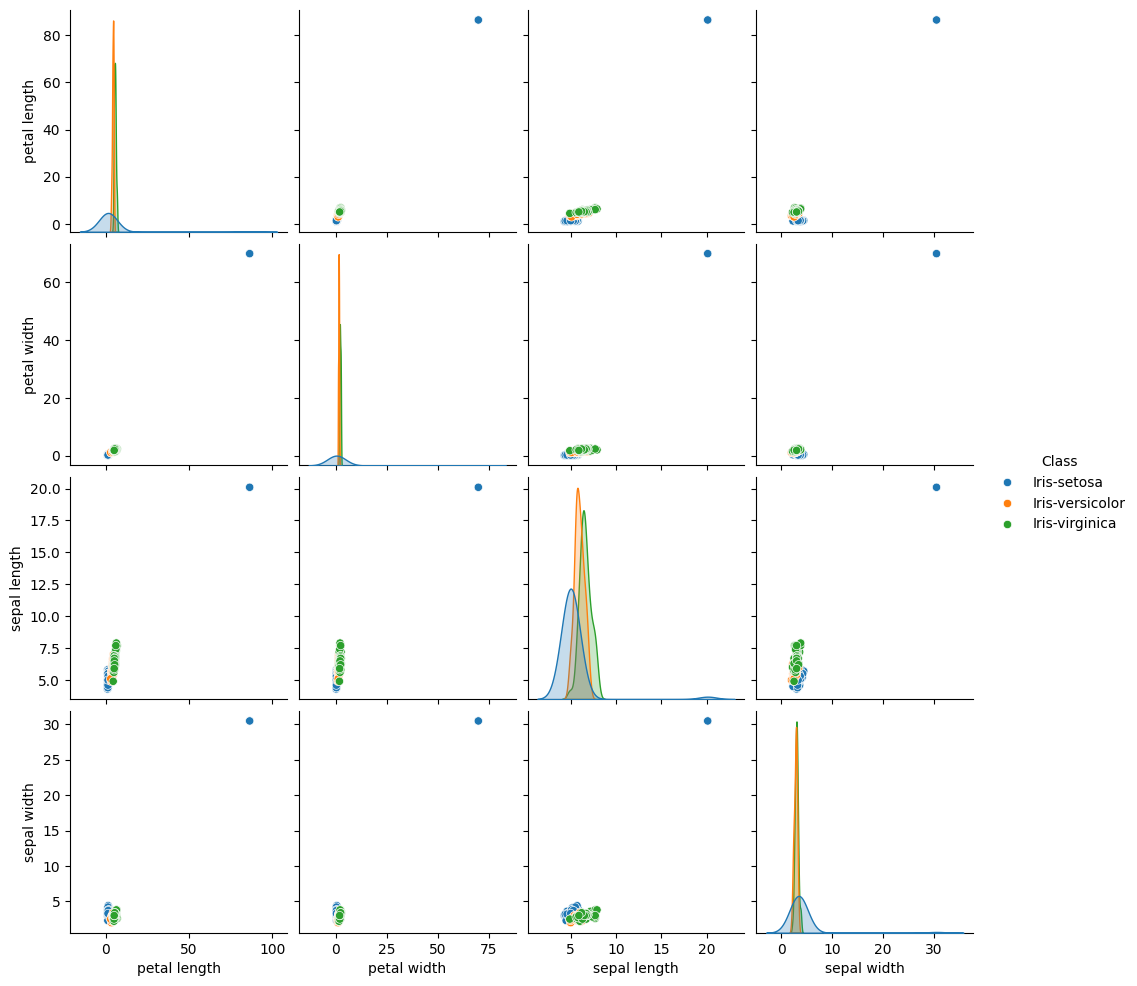

In [26]:
# Membuat pairplot untuk melihat hubungan antar fitur numerik berdasarkan kelas ('Class')
# Kolom 'id' dihapus karena tidak relevan dalam analisis
sns.pairplot(df_combined.drop(columns=["id"]), hue="Class")

# Menampilkan plot
plt.show()



Scatter plot matrix ini menunjukkan adanya **outlier ekstrem**:  

🔹 **Outlier Ekstrem**  
- Ada beberapa titik data yang jauh dari kumpulan data lainnya, terutama pada **petal length, petal width, sepal length, dan sepal width**.  
- Titik-titik ini tampaknya **tidak wajar** untuk dataset Iris, sehingga kemungkinan besar merupakan **kesalahan data atau pencatatan**.  

### 5. **Identifikasi masalah**
- deteksi missing value

In [54]:
# Mengecek jumlah missing value di setiap kolom
missing_values = df_combined.isnull().sum()

# Menampilkan hasil jika ada missing value
print("Jumlah Missing Value per Kolom:\n", missing_values)


Jumlah Missing Value per Kolom:
 id              0
Class           0
petal length    0
petal width     0
sepal length    0
sepal width     0
dtype: int64


- Deteksi outlier

In [55]:
# Menentukan Q1 (25%) dan Q3 (75%)
Q1 = df_combined.drop(columns=['id', 'Class']).quantile(0.25)
Q3 = df_combined.drop(columns=['id', 'Class']).quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menandai outlier (True jika di luar batas)
outliers = ((df_combined.drop(columns=['id', 'Class']) < lower_bound) |
            (df_combined.drop(columns=['id', 'Class']) > upper_bound))

# Menampilkan jumlah outlier per kolom
print("Jumlah Outlier per Kolom:\n", outliers.sum())


Jumlah Outlier per Kolom:
 petal length    1
petal width     1
sepal length    1
sepal width     5
dtype: int64


- **Identifikasi pola data**

Setelah memahami karakteristik dataset melalui eksplorasi data, diperlukan metode untuk **mengidentifikasi pola dalam dataset**. Salah satu metode yang cocok digunakan untuk **klasifikasi bunga iris** adalah **K-Nearest Neighbors (KNN)**.  



### **Apa Itu K-Nearest Neighbors (KNN)?**  

**K-Nearest Neighbors (KNN)** adalah metode berbasis **instance-based learning** yang mengklasifikasikan data berdasarkan **kemiripan dengan sampel lain dalam dataset**.  

- Tidak ada **pelatihan model eksplisit**, model hanya menyimpan data latih dan melakukan prediksi berdasarkan kedekatan dengan data baru.  
- Data baru akan dibandingkan dengan **K tetangga terdekat**, dan kelas yang paling banyak muncul akan digunakan sebagai prediksi.  

**Kelebihan KNN:**  
- Sederhana dan mudah diterapkan  
- Bisa digunakan untuk **klasifikasi dan regresi**  
- Tidak memerlukan asumsi distribusi data  

**Kekurangan KNN:**  
- **Kurang efisien untuk dataset besar**, karena perlu menghitung jarak ke semua titik data  
- **Sangat sensitif terhadap skala data dan outlier**  
- **Pemilihan K yang optimal perlu diuji terlebih dahulu**  

---

### **Langkah-Langkah KNN**  

1. **Hitung jarak** antara data baru dan semua data dalam dataset.
2. **Pilih K** tetangga terdekat.
3. **klasifikasi**: Ambil mayoritas kelas dari K tetangga.
4. Untuk regresi**: Ambil rata-rata nilai dari K tetangga.

---

### **Jenis-Jenis Metrik Jarak dalam KNN**  

Karena **KNN berbasis jarak**, pemilihan metrik sangat berpengaruh terhadap hasil prediksi.  

- **Euclidean Distance** (Paling umum digunakan)  
  - Rumus: √[(x₂ - x₁)² + (y₂ - y₁)²]
  
  Cocok untuk data kontinu dengan skala yang sama  

- **Manhattan Distance**  
  - Rumus: |x2-x1|+|y2-y1|
  
  Cocok untuk data yang lebih banyak berbentuk grid  

- **Minkowski Distance**  
  - Generalisasi euclidean dan manhattan

---

### **Pemilihan Nilai K yang Optimal**  

**Kecilnya nilai K → Overfitting**  
**Besar nilai K → Underfitting**  

- **Cara memilih K yang optimal:**  
  - Menggunakan **Cross Validation**  
  - Memilih **nilai K ganjil** untuk menghindari hasil voting yang imbang  
  - Mencari **nilai K dengan error terkecil** dalam validasi  

---

### **Implementasi KNN pada Dataset**  



1. Normalisasi data

In [43]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan label dari dataframe df_combined
X = df_combined.drop(columns=['id', 'Class'])  # Hanya fitur numerik
y = df_combined['Class']  # Target kelas

# Normalisasi data untuk memastikan skala seragam
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame
df_normalized = pd.DataFrame(X_scaled, columns=X.columns)
df_normalized['Class'] = y  # Tambahkan kembali kolom kelas

print("Data setelah normalisasi:")
print(df_normalized.head())


Data setelah normalisasi:
   petal length  petal width  sepal length  sepal width        Class
0     11.813913    12.096698      9.954547    11.985882  Iris-setosa
1     -0.421076    -0.259154     -0.733641    -0.102864  Iris-setosa
2     -0.435470    -0.259154     -0.874275    -0.014946  Iris-setosa
3     -0.406681    -0.259154     -0.944592    -0.058905  Iris-setosa
4     -0.421076    -0.259154     -0.663324     0.160890  Iris-setosa


2. Hitung Jarak (Euclidean Distance)

In [49]:
def euclidean_distance(row1, row2):
    """Menghitung jarak Euclidean antara dua titik"""
    return np.sqrt(np.sum((row1 - row2) ** 2))


3. Pilih K tetangga terdekat

In [50]:
def knn_find_neighbors(df, new_data, K=3):
    """
    Menghitung jarak dan memilih K tetangga terdekat.
    df: DataFrame yang sudah dinormalisasi
    new_data: Data uji (satu sampel)
    K: Jumlah tetangga yang dipilih
    """
    distances = []

    # Hitung jarak ke setiap titik dalam dataset
    for index, row in df.iterrows():
        dist = euclidean_distance(new_data, row[:-1])  # Semua kolom kecuali 'Class'
        distances.append((dist, row["Class"]))

    # Urutkan berdasarkan jarak terkecil
    distances.sort(key=lambda x: x[0])

    # Ambil K tetangga terdekat
    return distances[:K]


4. **Klasifikasi**: ambil mayoritas kelas

In [51]:
def knn_classify(neighbors):
    """
    Menentukan kelas berdasarkan mayoritas vote dari K tetangga.
    """
    classes = [neighbor[1] for neighbor in neighbors]  # Ambil kelas dari K tetangga
    predicted_class = max(set(classes), key=classes.count)  # Ambil kelas dengan frekuensi terbanyak
    return predicted_class


5. **Regresi**: ambil rata-rata nilai

In [52]:
def knn_regression(neighbors):
    """
    Menentukan nilai prediksi untuk regresi dengan mengambil rata-rata dari K tetangga.
    """
    values = [neighbor[1] for neighbor in neighbors]  # Ambil nilai target dari K tetangga
    predicted_value = np.mean(values)  # Hitung rata-rata
    return predicted_value


**Implementasi data baru**

In [53]:
# Data baru sebelum normalisasi
new_data_raw = np.array([[5.8, 2.7, 5.1, 1.9]])

# Konversi data baru ke DataFrame agar sesuai dengan fitur
new_data_df = pd.DataFrame(new_data_raw, columns=X.columns)

# Normalisasi data baru dengan scaler yang sudah dilatih
new_data_scaled = scaler.transform(new_data_df)

# Jalankan KNN untuk mendapatkan K tetangga terdekat
K = 5
neighbors = knn_find_neighbors(df_normalized, new_data_scaled[0], K)

# Prediksi kelas berdasarkan mayoritas voting
predicted_class = knn_classify(neighbors)

print("Prediksi kelas untuk data baru:", predicted_class)


Prediksi kelas untuk data baru: Iris-versicolor
